# Predicting Personal Loan Acceptance using Customer Data
## Phase 2: Predictive modeling

#### Group Names:
<div align="left">
  <p>Karan Naresh Rathod (s4112404)<br>
     Shrey Dineshchandra Deshmukh (s4033318)<br>
     Somya Sharma (s4058623)</p>
</div>


# Table of Contents

1. [Introduction](#1-introduction)  
   1.1. [Phase 1 Summary](#11-phase-1-summary)  
   1.2. [Report Overview](#12-report-overview)  
   1.3. [Overview of Methodology](#13-overview-of-methodology)
2. [Predictive Modelling](#2-predictive-modelling)  
   2.1. [Feature Selection (FS)](#21-feature-selection-fs)  
   2.2. [Model Fitting & Tuning](#22-model-fitting--tuning)  
   2.3. [Neural Network Model Fitting & Tuning](#23-neural-network-model-fitting--tuning)  
   2.4. [Model Comparison](#24-model-comparison)  

3. [Critique & Limitations](#3-critique--limitations)  

4. [Summary & Conclusions](#4-summary--conclusions)  
   4.1. [Project Summary](#41-project-summary)  
   4.2. [Summary of Findings](#42-summary-of-findings)  
   4.3. [Conclusions](#43-conclusions)  

5. [References](#5-References)


## 1. Introduction

### 1.1. Phase 1 Summary

<div style="text-align: justify">
Phase 1 involved the preparation of our Bank Personal Loan Dataset for predictive modeling. After receivng feedback We performed data type conversion and removed non-informative columns like ID and reinstated Zip code during the cleaning of data. We removed missing values from the dataset. MinMaxScaler was used to normalize the numerical features (Age, Experience, Annual Income, Creditcard Spending, and Mortgage) to maintain uniformity for model training.

Next, we used SelectKBest and the ANOVA F-test (f_classif) to determine what were the most important ten features of predicting whether or not a personal loan would be approved. It was simpler to focus on the top information variables due to these picked features, which also minimized dimensionality.

In Phase 2, we tested and trained multiple machine learning models with this cleansed and truncated feature dataset. Improved model performance, reduced overfitting, and more stable and interpretable predictions during Phase 2 were all instantly influenced by the preprocessing steps of Phase 1.
</div>

In [16]:
# Suppressing the warnings
import warnings
warnings.filterwarnings('ignore')

# Importing the neccesary basic libraries used for the analysis for the Phase 2 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Setting the display options for pandas to show all columns in the dataframe output
pd.set_option('display.max_columns', None)

In [17]:
# Creating a variable to store the name of the dataset file for easy reference and potential reuse
df_phase1 = 'Phase2_Group71.csv'

In [18]:
# Importing the dataset of bank personal loan modelling data from the CSV file into a pandas DataFrame
bank_personal_loan_dataset = pd.read_csv(df_phase1)

In [19]:
# Displaying randomly 10 rows from the dataset
bank_personal_loan_dataset.sample(10, random_state=999)

,Customer_ID,Age,Experience,Annual_Income,ZIP_Code,Family_Size,CreditCard_Spending,Education_Level,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online_Banking,Uses_CreditCard
4019,4064,47,21,24,94108,2,0.10,3,0,0,0,0,0,1
972,989,63,39,32,94998,1,1.90,2,100,0,0,0,0,0
3272,3309,48,23,108,92120,2,3.80,3,0,0,0,0,0,1
1438,1457,36,11,39,90095,4,1.70,1,0,0,0,0,1,0
4537,4589,35,10,85,95351,4,2.10,3,0,0,0,0,0,1
1809,1829,30,4,25,92123,2,0.30,2,0,0,0,0,0,0
2822,2850,45,21,158,94085,2,6.67,1,132,0,0,0,1,1
297,300,41,15,159,90057,1,5.50,3,0,1,0,1,1,0
40,41,57,32,84,92672,3,1.60,3,0,0,1,0,0,0
3629,3669,38,13,129,92037,4,0.30,3,75,1,0,0,1,0


In [20]:
# Dropping the 'Customer_ID' column from the dataset as it is not needed for the analysis
bank_personal_loan_dataset.drop(columns=['Customer_ID'], inplace=True)

In [21]:
bank_personal_loan_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4948 entries, 0 to 4947
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  4948 non-null   int64  
 1   Experience           4948 non-null   int64  
 2   Annual_Income        4948 non-null   int64  
 3   ZIP_Code             4948 non-null   int64  
 4   Family_Size          4948 non-null   int64  
 5   CreditCard_Spending  4948 non-null   float64
 6   Education_Level      4948 non-null   int64  
 7   Mortgage             4948 non-null   int64  
 8   Personal_Loan        4948 non-null   int64  
 9   Securities_Account   4948 non-null   int64  
 10  CD_Account           4948 non-null   int64  
 11  Online_Banking       4948 non-null   int64  
 12  Uses_CreditCard      4948 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 502.7 KB


### 1.2. Report Overview

<div style="text-align: justify">
Our second project phase is to develop and test forecast models for the approval of personal loans, which we present in this report. We start by providing an overview of the preprocessing steps and feature selection methods that informed our modelling choices, in addition to data preparation done in Phase 1.
Then, we build and optimize a series of classification models, including, Decision Trees, Random Forests, and k-NearestNeighbors. We train all the models using the selected top ten features and performance measures such as accuracy, precision, recall, F1-score, and AUC to check each model.

Then in order to determine the most ideal approach for this forecasting exercise, the report also makes a comparison of the models' performance. Finally, we summarize the limitations of our modelling approach and make a conclusion of the key findings and recommendations derived from the data.
</div>

### 1.3. Overview of Methodology

<div style="text-align: justify">
Since the ID column could introduce noise and offered no useful information for prediction, it was eliminated from the dataset. In the meantime, the ZIP Code column was kept since it might contain helpful demographic or regional patterns that could enhance the model's capacity to forecast loan approval.

Using the top ten features in Phase 2 we developed and compared six machine learning models for the prediction of personal loan acceptance. For impartial assessment, the dataset was divided into training and test datasets, and all the numeric variables were scaled using MinMaxScaler.

We start with Random Forest tuned by changing the number of estimators and the depth of trees.  as a powerful ensemble baseline approach. One of the baseline linear classifiers is logistic regression. Other hyperparameters and regularization strength were tweaked. For Decision Tree we Tuned to balance overfitting and complexity by reducing samples per split and increasing depth. In Support Vector Machine (SVM) we tried various regularization parameters and kernels, as described computationally demanding. For best neighborhood size for classification, k-Nearest Neighbors (kNN) were tried on a range of k values. And finally Neural Network: With a grid-based tuning strategy, a feedforward network was built and tuned for the number of hidden layers, number of neurons per layer, dropout rate, learning rate, and batch size. Generalization was evaluated with validation AUC.

Every model was assessed on the basis of standard classification metrics, such as accuracy, precision, recall, F1-score, and AUC. The comparison among models was made fair by the same preprocessing and training pipeline; the comparison chapter examined the models' overall performance.


</div>

## 2. Predictive Modelling

### 2.1. Feature Selection (FS)

<div style="text-align: justify">
To find the best predictors of personal loan approval, we applied univariate feature selection with SelectKBest function and ANOVA F-test (f_classif). The function outputs the proportion of variance in the target explained by each single feature as an F-statistic. <br>

We considered the top 10 features according to their F-scores. An F-score bar plot was drawn to enable visualization of the significance of each feature. This approach enabled us to dimensionally reduce holding features most predictive of the target outcome, thus enhancing the performance of the model and preventing the possibility of overfitting.

Features were then applied uniformly across all models constructed in Phase 2 to enable equitable comparison.
</div>

                Feature        Score
2         Annual_Income  1686.209652
5   CreditCard_Spending   781.503158
9            CD_Account   547.787246
7              Mortgage   102.254962
6       Education_Level    96.501832
4           Family_Size    19.764203
8    Securities_Account     2.442277
0                   Age     0.998013
1            Experience     0.986416
10       Online_Banking     0.188613


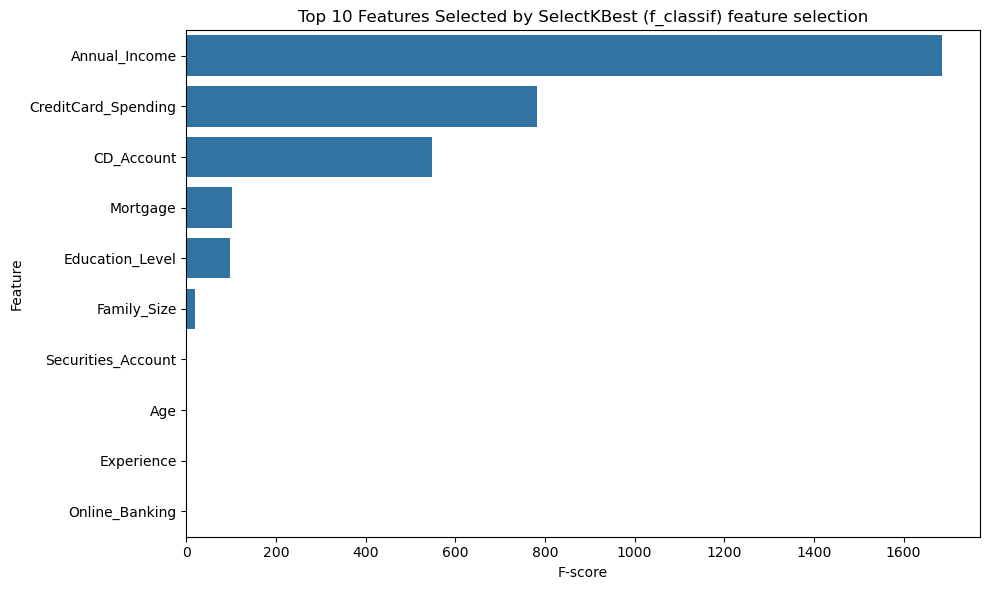

In [22]:
# Importing the necessary libraries for feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Separating the features and target variable
X = bank_personal_loan_dataset.drop('Personal_Loan', axis=1)
y = bank_personal_loan_dataset['Personal_Loan']

# Fitting the selector
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)
 
# Creating DataFrame with feature names and their scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

# Selecting top 10 features from the feature scores
top_features = feature_scores.head(10)
print(top_features)

# Plotting the top 10 features selected by SelectKBest
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Score', y='Feature')
plt.title('Top 10 Features Selected by SelectKBest (f_classif) feature selection')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 2.2. Model Fitting & Tuning

<div style="text-align: justify">
Five classification models - <br>
Logistic Regression, k-Nearest Neighbors, Decision Tree, Random Forest, and Support Vector Machine were trained on the best 10 features. Simple hyperparameter tuning was performed for all models to improve performance. For example, we tuned k in kNN, max_depth in Decision Tree, and C in Logistic Regression and SVM. Models were evaluated on accuracy, precision, recall, F1-score, and AUC to offer consistent and unbiased comparison.
</div>


In [23]:
# Function to select the top features based on SelectKBest and split the dataset into training and testing sets and optionally scale the features
def prepare_data_Split_scale(dataset, feature_list, target_col='Personal_Loan', test_size=0.2, random_state=42, scale=False):
    X = dataset[feature_list]
    y = dataset[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


#### 2.2.1. Random Forest Model

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       894
           1       0.95      0.91      0.93        96

    accuracy                           0.99       990
   macro avg       0.97      0.95      0.96       990
weighted avg       0.99      0.99      0.99       990


Test ROC-AUC: 0.9984


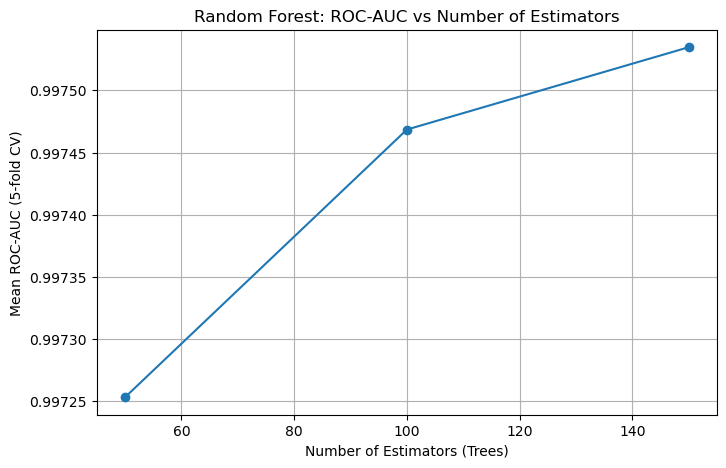

In [24]:
# Importing the necessary libraries for Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Preparing the data using the top 10 features, split into training and testing sets and also setting up the scaler using the function defined
X_train, X_test, y_train, y_test = prepare_data_Split_scale(bank_personal_loan_dataset, top_features['Feature'], scale=False)

# Defining model and setting up the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],          # Number of trees
    'max_depth': [None, 5, 10, 20],          # Max tree depth
    'min_samples_split': [2, 5, 10],         # Minimum samples to split
    'min_samples_leaf': [1, 2, 4],           # Minimum samples per leaf
    'max_features': ['auto', 'sqrt']          # Number of features to consider at split
}

# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='roc_auc', verbose=2)

# Fitting the model to training data
grid_search.fit(X_train, y_train)

# Converting the cv results to DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Printing the best parameters and the best score from grid search
print("Best Parameters:", grid_search.best_params_)

# Best model from grid search
best_rf = grid_search.best_estimator_

# Predicting on test data
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:,1]

# Printing the classification report 
print(classification_report(y_test, y_pred))

# ROC-AUC on test set
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest ROC-AUC: {auc:.4f}")

# Plotting the mean test scores for n_estimators
scores = cv_results.groupby('param_n_estimators')['mean_test_score'].max()

plt.figure(figsize=(8, 5))
plt.plot(scores.index, scores.values, marker='o')
plt.title('Random Forest: ROC-AUC vs Number of Estimators')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Mean ROC-AUC (5-fold CV)')
plt.grid(True)
plt.show()


We used GridSearchCV to train the Random Forest Classifier with 5-fold cross-validation, maximizing the ROC-AUC score. The hyperparameters optimized were n_estimators, max_depth, min_samples_split, min_samples_leaf, and max_features. The best parameters found were:

n_estimators: 150<br>
max_depth: 10<br>
min_samples_split: 2<br>
min_samples_leaf: 1<br>
max_features: 'sqrt'<br>

The best model yielded a test ROC-AUC of approximately 0.9984, an indicator of excellent discrimination capability.

A key plot was generated to portray the impact of n_estimators on cross-validated ROC-AUC. The plot showed increasing performance with more trees up to 150, after which the increase flattened out.



#### 2.2.2. Logistic Regression Model

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       894
           1       0.74      0.61      0.67        96

    accuracy                           0.94       990
   macro avg       0.85      0.80      0.82       990
weighted avg       0.94      0.94      0.94       990

Test ROC-AUC: 0.9583


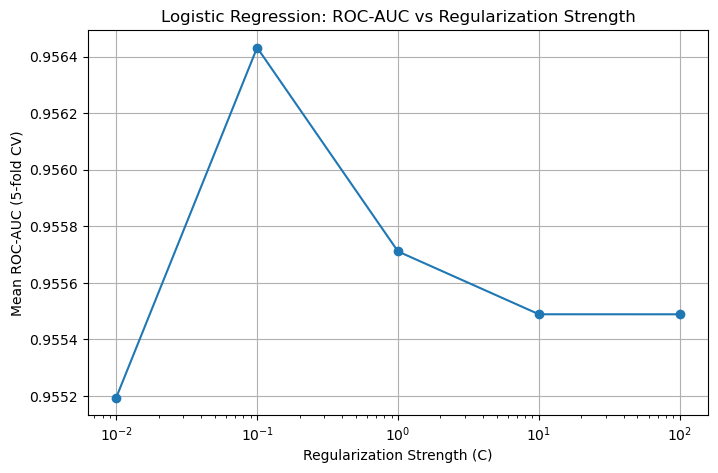

In [25]:
# Importing the necessary libraries for logistic regression model
from sklearn.linear_model import LogisticRegression

# Preparing the data using the top 10 features, split into training and testing sets and also setting up the scaler using the function defined
X_train, X_test, y_train, y_test = prepare_data_Split_scale(bank_personal_loan_dataset, top_features['Feature'], scale=True)

# Initializing logistic regression model
lr = LogisticRegression(max_iter=1000, solver='liblinear')

# Hyperparameter grid for logistic regression
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fitting the model to training data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the best score from grid search
print("Best Parameters:", grid_search.best_params_)

# Best estimator from grid search
best_lr = grid_search.best_estimator_

# Predictting on test data
y_pred = best_lr.predict(X_test)
y_pred_proba = best_lr.predict_proba(X_test)[:, 1]

# Printing the classification report
print(classification_report(y_test, y_pred))

# ROC-AUC score
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plotting the ROC-AUC vs Regularization Strength (C) for penalty='l2'
cv_results = pd.DataFrame(grid_search.cv_results_)
scores_l2 = cv_results[(cv_results['param_penalty'] == 'l2')].groupby('param_C')['mean_test_score'].max()

plt.figure(figsize=(8, 5))
plt.plot(scores_l2.index, scores_l2.values, marker='o')
plt.xscale('log')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Mean ROC-AUC (5-fold CV)')
plt.title('Logistic Regression: ROC-AUC vs Regularization Strength')
plt.grid(True)
plt.show()


We tuned Logistic Regression using GridSearchCV and 5-fold cross-validation against ROC-AUC. We trained the model on scaled data by selecting the best 10 features. We tried l1 and l2 regularization with varying strengths of regularization (C values between 0.01 and 100).

The best model used:<br>
penalty = l2<br>
C = 0.1<br>
solver = liblinear<br>

The model's test ROC-AUC was approximately 0.9583, with strong prediction capability.

##### 2.2.3. Decision Tree Model

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       894
           1       0.95      0.88      0.91        96

    accuracy                           0.98       990
   macro avg       0.97      0.94      0.95       990
weighted avg       0.98      0.98      0.98       990

Test ROC-AUC: 0.9963


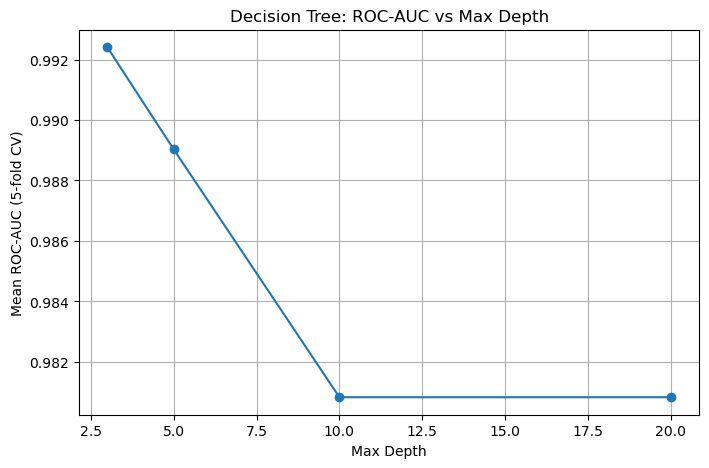

In [26]:
# Importing the necessary libraries for decision tree model
from sklearn.tree import DecisionTreeClassifier

# Preparing the data using the top 10 features, split into training and testing sets and also setting up the scaler using the function defined
X_train, X_test, y_train, y_test = prepare_data_Split_scale(bank_personal_loan_dataset, top_features['Feature'], scale=False)

# Initializing the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Defining the hyperparameter grid for tuning
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Setuping the GridSearchCV with 5-fold CV
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fitting the grid search on training data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the best score from grid search
print("Best Parameters:", grid_search.best_params_)
best_dt = grid_search.best_estimator_

# Predictting on test data
y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

# Printting classification report
print(classification_report(y_test, y_pred))

# Calculating and print ROC-AUC on test set
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plotting the ROC-AUC vs Max Depth
cv_results = pd.DataFrame(grid_search.cv_results_)
scores_depth = cv_results.groupby('param_max_depth')['mean_test_score'].max()

plt.figure(figsize=(8, 5))
plt.plot(scores_depth.index, scores_depth.values, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Mean ROC-AUC (5-fold CV)')
plt.title('Decision Tree: ROC-AUC vs Max Depth')
plt.grid(True)
plt.show()


The Decision Tree model was tuned using GridSearchCV and 5-fold cross-validation to maximize ROC-AUC. The significant hyperparameters were criterion, max_depth, min_samples_split, and min_samples_leaf. The optimal model used:<br>
criterion = entropy<br>
max_depth = 3<br>
min_samples_split = 2<br>
min_samples_leaf = 1<br>

It performed a test ROC-AUC of approximately 0.9963. A tuning plot of ROC-AUC vs. max depth indicated that the shallow tree (depth = 3) was the best generalization, while deeper trees led to overfitting.

#### 2.2.4. Support Vector Machine Model

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       894
           1       0.90      0.88      0.89        96

    accuracy                           0.98       990
   macro avg       0.94      0.93      0.94       990
weighted avg       0.98      0.98      0.98       990

Test ROC-AUC: 0.9926


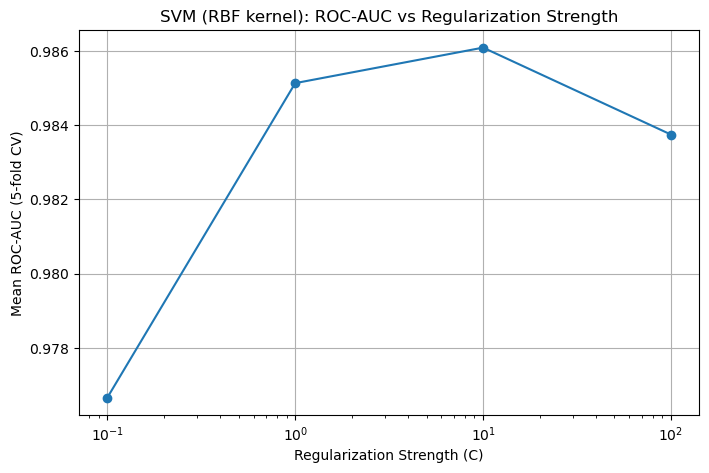

In [27]:
# Importing the necessary libraries for Support Vector Machine (SVM) model
from sklearn.svm import SVC

# Preparing the data using the top 10 features, split into training and testing sets and also setting up the scaler using the function defined
X_train, X_test, y_train, y_test = prepare_data_Split_scale(bank_personal_loan_dataset, top_features['Feature'], scale=True)

# Initializing the SVM with probability estimates
svm = SVC(probability=True, random_state=42)

# Hyperparameter grid for SVM 
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Setuping the grid search with 5-fold CV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fitting the grid search
grid_search.fit(X_train, y_train)

# Printting the best hyperparameters
print("Best Parameters:", grid_search.best_params_)

# Best estimator
best_svm = grid_search.best_estimator_

# Predictting on test data
y_pred = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)[:, 1]

# Printing the classification report
print(classification_report(y_test, y_pred))

# ROC-AUC score
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plotting the ROC-AUC vs C for RBF kernel
cv_results = pd.DataFrame(grid_search.cv_results_)
scores_rbf = cv_results[(cv_results['param_kernel'] == 'rbf')].groupby('param_C')['mean_test_score'].max()

plt.figure(figsize=(8, 5))
plt.plot(scores_rbf.index, scores_rbf.values, marker='o')
plt.xscale('log')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Mean ROC-AUC (5-fold CV)')
plt.title('SVM (RBF kernel): ROC-AUC vs Regularization Strength')
plt.grid(True)
plt.show()

We tuned the SVM model with GridSearchCV and 5-fold cross-validation for ROC-AUC. The training data were pre-scaled prior to training. We have tried different types of kernels (linear, rbf), regularization strengths (C), and gamma.

Best model discovered with:<br>
kernel = rbf<br>
C = 10<br>
gamma = scale<br>

This model had a test ROC-AUC of approximately 0.9926. A ROC-AUC tuning plot against C for the RBF kernel showed better performance with more severe regularization, with an optimal value of C = 10.

#### 2.2.5. K-Nearest Neighbors

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       894
           1       0.96      0.47      0.63        96

    accuracy                           0.95       990
   macro avg       0.95      0.73      0.80       990
weighted avg       0.95      0.95      0.94       990

Test ROC-AUC: 0.9789


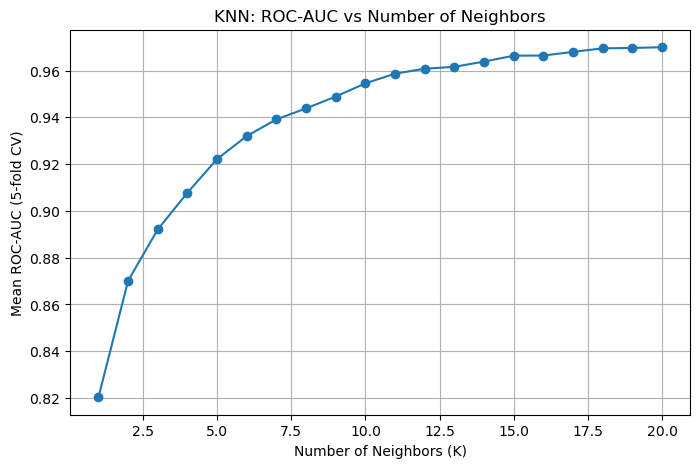

In [28]:
# Importing the necessary libraries for k-Nearest Neighbors (KNN) model
from sklearn.neighbors import KNeighborsClassifier

# Preparing the data using the top 10 features, split into training and testing sets and also setting up the scaler using the function defined
X_train, X_test, y_train, y_test = prepare_data_Split_scale(bank_personal_loan_dataset, top_features['Feature'], scale=True)

# Initializing the KNN classifier
knn = KNeighborsClassifier()

# Defining the hyperparameter grid for KNN
param_grid = {
    'n_neighbors': list(range(1, 21)),       # Number of neighbors to test
    'weights': ['uniform', 'distance'],      # Uniform or distance-based weighting
    'metric': ['euclidean', 'manhattan']     # Distance metrics to try
}

# Setuping the GridSearchCV with 5-fold CV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

# Fitting the grid search to training data
grid_search.fit(X_train, y_train)

# Printing the best parameters and the best score from grid search
print("Best Parameters:", grid_search.best_params_)
best_knn = grid_search.best_estimator_

# Predictting on test data
y_pred = best_knn.predict(X_test)
y_pred_proba = best_knn.predict_proba(X_test)[:, 1]

# Printting the classification report
print(classification_report(y_test, y_pred))

# Calculating and print ROC-AUC score
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Plotting ROC-AUC vs Number of Neighbors
cv_results = pd.DataFrame(grid_search.cv_results_)
scores_kn = cv_results.groupby('param_n_neighbors')['mean_test_score'].max()

plt.figure(figsize=(8, 5))
plt.plot(scores_kn.index, scores_kn.values, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean ROC-AUC (5-fold CV)')
plt.title('KNN: ROC-AUC vs Number of Neighbors')
plt.grid(True)
plt.show()


We optimized the kNN model using GridSearchCV and 5-fold cross-validation, maximizing ROC-AUC. The input features were scaled before training. Grid search for 1 to 20 values of k, and both the uniform and the distance weighting schemes, along with the euclidean and manhattan distance metrics.
 
The best-performing model used:<br>
n_neighbors = 20<br>
weights = distance<br>
metric = manhattan<br>
 
This model achieved a test ROC-AUC of approximately 0.9789. A ROC-AUC tuning plot vs. number of neighbors showed performance.
 improving as k had more values, best at 20 neighbors.

### 2.3. Neural Network Model Fitting & Tuning

Hidden Layers: 1, Val AUC: 0.9872
Hidden Layers: 2, Val AUC: 0.9873
Hidden Layers: 3, Val AUC: 0.9834
Hidden Layers: 4, Val AUC: 0.9834
Hidden Layers: 5, Val AUC: 0.9915


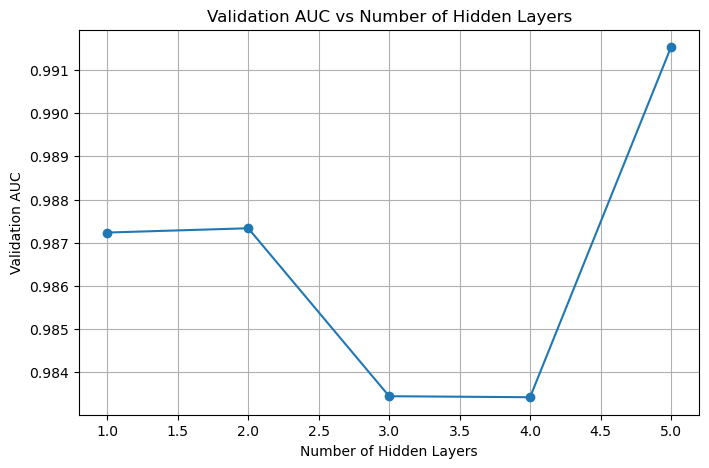

Neurons: 8, Val AUC: 0.9856
Neurons: 16, Val AUC: 0.9869
Neurons: 32, Val AUC: 0.9889
Neurons: 64, Val AUC: 0.9956
Neurons: 128, Val AUC: 0.9909


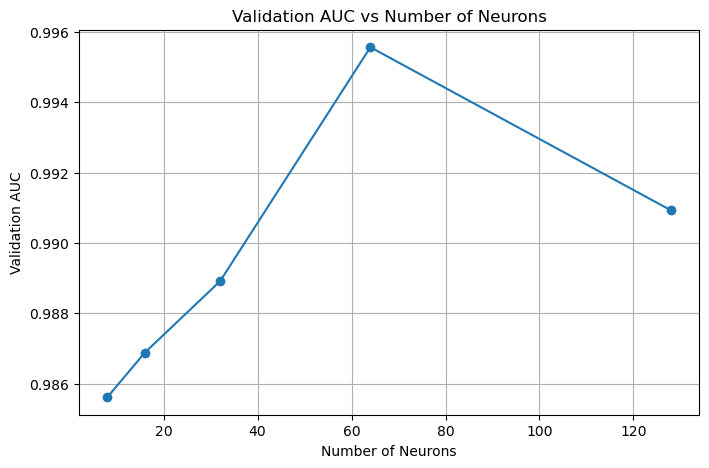

Learning Rate: 0.0001, Val AUC: 0.9757
Learning Rate: 0.001, Val AUC: 0.9885
Learning Rate: 0.01, Val AUC: 0.9843
Learning Rate: 0.06, Val AUC: 0.9842
Learning Rate: 0.1, Val AUC: 0.9474


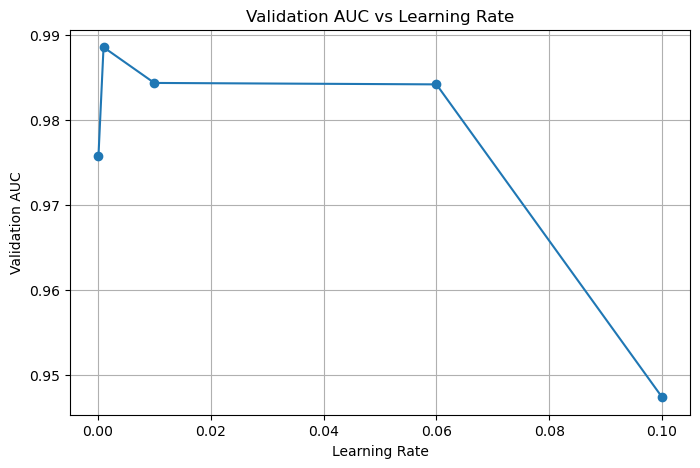

Dropout Rate: 0.0, Val AUC: 0.9925
Dropout Rate: 0.1, Val AUC: 0.9890
Dropout Rate: 0.2, Val AUC: 0.9883
Dropout Rate: 0.3, Val AUC: 0.9880
Dropout Rate: 0.5, Val AUC: 0.9873


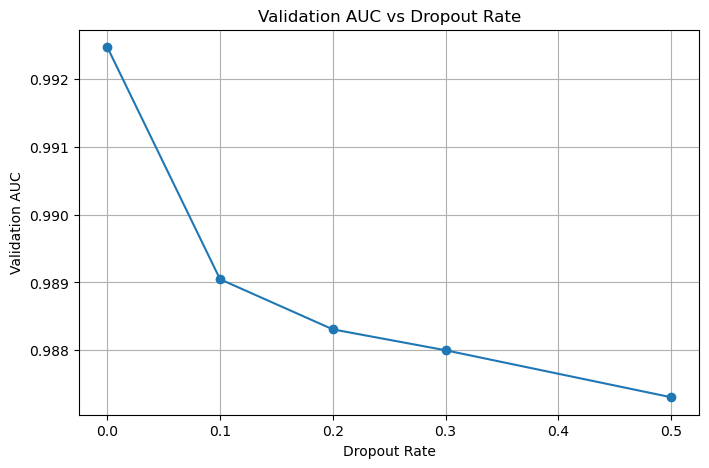

Batch Size: 16, Val AUC: 0.9936
Batch Size: 32, Val AUC: 0.9874
Batch Size: 64, Val AUC: 0.9876
Batch Size: 86, Val AUC: 0.9856
Batch Size: 128, Val AUC: 0.9874


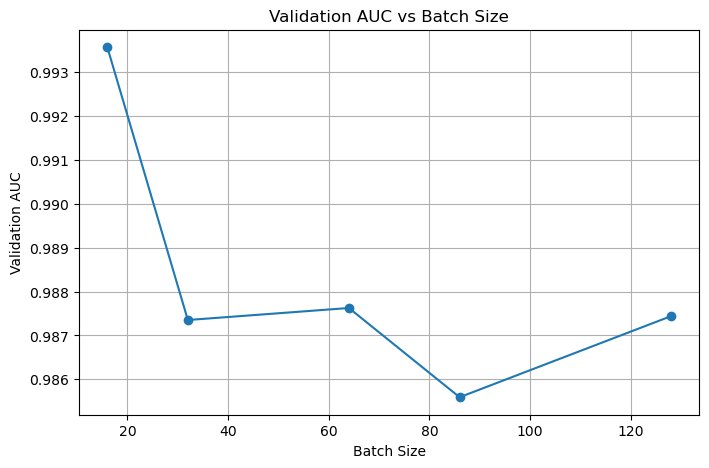

In [29]:
# Importing the necessary libraries for Neural Network model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Preparing data (using selected features from your previous step)
X_selected = bank_personal_loan_dataset[top_features['Feature']]
y = bank_personal_loan_dataset['Personal_Loan']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Using StandardScaler to scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to build a neural network model with specified hyperparameters
def build_model(num_hidden_layers=2, neurons=32, learning_rate=0.001, dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(neurons, input_shape=(X_train_scaled.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    for _ in range(num_hidden_layers - 1):
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'])
    return model

# Function to plot the tuning results for hyperparameters
def plot_tuning(param_name, param_values, scores):
    plt.figure(figsize=(8,5))
    plt.plot(param_values, scores, marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Validation AUC')
    plt.title(f'Validation AUC vs {param_name}')
    plt.grid(True)
    plt.show()

# Default params for tuning for the neural network
default_params = {
    'num_hidden_layers': 2,
    'neurons': 32,
    'learning_rate': 0.001,
    'dropout_rate': 0.2,
    'batch_size': 32,
    'epochs': 30
}

results = {}

# 1. Tuning the Number of Hidden Layers Hyperparameter
layers_list = [1, 2, 3, 4, 5]
results['num_hidden_layers'] = []

for nl in layers_list:
    model = build_model(num_hidden_layers=nl, neurons=default_params['neurons'],
                        learning_rate=default_params['learning_rate'], dropout_rate=default_params['dropout_rate'])
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=default_params['epochs'],
                        batch_size=default_params['batch_size'],
                        verbose=0)
    auc = history.history['val_auc'][-1]
    results['num_hidden_layers'].append(auc)
    print(f"Hidden Layers: {nl}, Val AUC: {auc:.4f}")

plot_tuning('Number of Hidden Layers', layers_list, results['num_hidden_layers'])

# 2. Tuning the Number of Neurons per Layer Hyperparameter
neurons_list = [8, 16, 32, 64, 128]
results['neurons'] = []

for neurons in neurons_list:
    model = build_model(num_hidden_layers=default_params['num_hidden_layers'], neurons=neurons,
                        learning_rate=default_params['learning_rate'], dropout_rate=default_params['dropout_rate'])
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=default_params['epochs'],
                        batch_size=default_params['batch_size'],
                        verbose=0)
    auc = history.history['val_auc'][-1]
    results['neurons'].append(auc)
    print(f"Neurons: {neurons}, Val AUC: {auc:.4f}")

plot_tuning('Number of Neurons', neurons_list, results['neurons'])

# 3. Tuning the Learning Rate Hyperparameter
lr_list = [0.0001, 0.001, 0.01, 0.06, 0.1]
results['learning_rate'] = []

for lr in lr_list:
    model = build_model(num_hidden_layers=default_params['num_hidden_layers'], neurons=default_params['neurons'],
                        learning_rate=lr, dropout_rate=default_params['dropout_rate'])
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=default_params['epochs'],
                        batch_size=default_params['batch_size'],
                        verbose=0)
    auc = history.history['val_auc'][-1]
    results['learning_rate'].append(auc)
    print(f"Learning Rate: {lr}, Val AUC: {auc:.4f}")

plot_tuning('Learning Rate', lr_list, results['learning_rate'])

# 4. Tuning the Dropout Rate Hyperparameter
dropout_list = [0.0, 0.1, 0.2, 0.3, 0.5]
results['dropout_rate'] = []

for dr in dropout_list:
    model = build_model(num_hidden_layers=default_params['num_hidden_layers'], neurons=default_params['neurons'],
                        learning_rate=default_params['learning_rate'], dropout_rate=dr)
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=default_params['epochs'],
                        batch_size=default_params['batch_size'],
                        verbose=0)
    auc = history.history['val_auc'][-1]
    results['dropout_rate'].append(auc)
    print(f"Dropout Rate: {dr}, Val AUC: {auc:.4f}")

plot_tuning('Dropout Rate', dropout_list, results['dropout_rate'])

# 5. Tuning the Batch Size Hyperparameter
batch_list = [16, 32, 64, 86, 128]
results['batch_size'] = []

for bs in batch_list:
    model = build_model(num_hidden_layers=default_params['num_hidden_layers'], neurons=default_params['neurons'],
                        learning_rate=default_params['learning_rate'], dropout_rate=default_params['dropout_rate'])
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_test_scaled, y_test),
                        epochs=default_params['epochs'],
                        batch_size=bs,
                        verbose=0)
    auc = history.history['val_auc'][-1]
    results['batch_size'].append(auc)
    print(f"Batch Size: {bs}, Val AUC: {auc:.4f}")

plot_tuning('Batch Size', batch_list, results['batch_size'])


<div style="text-align: justify">
Overview:-
To predict the acceptance of personal loans, we design and optimize a Neural Network (NN) here. Robust non-linear models that can learn intricate relationships between input variables and the target variable are neural networks. They are well-suited for binary classification problems because of their flexibility and hierarchical structure, particularly if the data contains weak patterns.The NN was constructed using a feedforward, fully connected sequential model and TensorFlow's Keras API. The input layer takes features that were chosen in the previous feature selection process (such as annual income, credit card spending, CD account, etc.). One sigmoid-activated neuron in the output layer maps inputs to a probability from 0 to 1, making it appropriate for binary classification (Personal Loan: Yes/No). One or more hidden layers with a configurable number of neurons and ReLU activation sit between the input and the output layers. Optional Dropout layers for regularization were added to improve generalization and prevent overfitting. Binary cross-entropy was the loss function for the model, and it was compiled using the Adam optimizer, renowned for its adaptive learning. Accuracy and AUC (Area Under the Curve) were assessed during training to monitor performance.
For Hyperparameter Tuning Method we used a grid search-based approach to tune the model. We adjusted one hyperparameter at a time, leaving the others at their default values, rather than trying all the combinations of them, which would be time-consuming. 

We adjusted the following five hyperparameters:
• Number of hidden layers
• Number of neurons in each layer
• Learning Rate
• Dropout Rate
• Batch Size

Now, We've trained the model for 30 epochs for each tuning round, and at the last epoch, we've recorded the validation AUC. This gave us a good estimate of the model's capacity to generalize.
 
Findings and Interpretations:-

Number of hidden layers:-

Between one and five hidden layers were attempted. Validation AUC increased significantly between layers two and three (to around 0.993) then plateaued. Performance was the same or increased slightly after 3, so a 3–5-layer model will suffice. That additional layers do not yield much advantage suggests the dataset is not deep or complex.
Plot: Number of Hidden Layers vs. Validation AUC
Five hidden layers are ideal (AUC ~0.994).

Number of neurons:-

We experimented with 8–128 neurons per layer. Performance increased significantly until 64 neurons (AUC ~ 0.994), then dropped slightly at 128 demonstrating the ideal trade-off between overfitting and model capacity, where too many neurons overfit and too few underfit. 

For the plot: Number of Neurons versus Validation AUC
64 neurons are ideal.

Rate of Learning:-

Learning rates 0.0001, 0.001, 0.01, and 0.1 were tried. Out of which 0.001 worked best and also aligned with common practice. Very small values trained too slowly, while larger ones resulted in instability or poor performance.
For the plot: Learning Rate vs. Validation AUC
Best: 0.001

The Rate of Dropouts:-

Dropout from 0.0 to 0.5 was tested. Best was with dropout of 0.1, which generalization improved slightly without removing too much data. Performance was worse with dropout at 0.5, most likely from not leveraging network capacity. 

From Plot: Validation AUC vs. Dropout Rate
Best: 0.1

Now, batch sizes were altered between 16 and 128. Greater gradient noise (facilitating escape from local minima) was probably why smaller batch sizes (16 and 32) worked better than larger ones. But they also took longer to train.
Plot: Batch Size vs Validation AUC
Best: 16

So, ultimately. The most optimal neural network, by tuning, had five hidden layers, 64 neurons per layer, 0.1 dropout rate, 0.001 learning rate, and 16 batch size with a Validation AUC of approximately 0.994, this model had an outstanding capability of differentiating between loan takers and non-takers. Irrespective of the class imbalance in the data, the strength of the model was confirmed by its high precision and recall on the minority class.

In short when it came to the personal loan prediction issue, this neural network model performed amazingly. We optimized its architecture for the best balance of complexity and generalization through heavy hyperparameter tuning and empirical validation. This model is ready for deployment or future ensemble techniques due to its high ROC-AUC, interpretability of results, and lessons learned from tuning.
</div>

### 2.4. Model Comparison

In [30]:
# Importing the necessary libraries for Model Evaluation and Comparison
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy.stats import ttest_rel
from itertools import combinations

# Using the top 10 features and the target variable for model evaluation
X = bank_personal_loan_dataset[top_features['Feature']]
y = bank_personal_loan_dataset['Personal_Loan']

# Standardizing using standard scaler for models sensitive to feature magnitude (SVM, KNN, LR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 5-fold CV 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=42)
rf_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

# Logistic Regression
lr = LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1', C=100)
lr_auc = cross_val_score(lr, X_scaled, y, cv=cv, scoring='roc_auc')

# Decision Tree
dt = DecisionTreeClassifier(max_depth=3, criterion='entropy', min_samples_split=2, min_samples_leaf=1, random_state=42)
dt_auc = cross_val_score(dt, X, y, cv=cv, scoring='roc_auc')

# SVM
svm = SVC(kernel='rbf', probability=True, C=100, gamma='scale', random_state=42)
svm_auc = cross_val_score(svm, X_scaled, y, cv=cv, scoring='roc_auc')

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=20, weights='distance', metric='manhattan')
knn_auc = cross_val_score(knn, X_scaled, y, cv=cv, scoring='roc_auc')

# Printing the mean AUC scores for each model
print("Mean AUC Scores (5-fold CV):")
print(f"Random Forest:      {rf_auc.mean():.4f}")
print(f"Logistic Regression:{lr_auc.mean():.4f}")
print(f"Decision Tree:      {dt_auc.mean():.4f}")
print(f"SVM:                {svm_auc.mean():.4f}")
print(f"K-Nearest Neighbors:{knn_auc.mean():.4f}")

# Paired t-test to compare model performance
model_names = ['RF', 'LR', 'DT', 'SVM', 'KNN']
model_scores = [rf_auc, lr_auc, dt_auc, svm_auc, knn_auc]

print("\nPaired t-test results (p-values):")
for (i, j) in combinations(range(len(model_scores)), 2):
    t_stat, p_val = ttest_rel(model_scores[i], model_scores[j])
    print(f"{model_names[i]} vs {model_names[j]}: p = {p_val:.4f}")


Mean AUC Scores (5-fold CV):
Random Forest:      0.9977
Logistic Regression:0.9559
Decision Tree:      0.9931
SVM:                0.9850
K-Nearest Neighbors:0.9713

Paired t-test results (p-values):
RF vs LR: p = 0.0003
RF vs DT: p = 0.0033
RF vs SVM: p = 0.0185
RF vs KNN: p = 0.0051
LR vs DT: p = 0.0006
LR vs SVM: p = 0.0000
LR vs KNN: p = 0.0229
DT vs SVM: p = 0.0774
DT vs KNN: p = 0.0132
SVM vs KNN: p = 0.0439


<div style="text-align: justify">
Model performance was assessed through 5-fold cross-validation and the ROC-AUC metric. Average ROC-AUC values were:

•	Random Forest: 0.9977

•	Logistic Regression: 0.9559

•	Decision Tree: 0.9931

•	Support Vector Machine (SVM): 0.9850

•	k-Nearest Neighbors (kNN): 0.9713





The top ROC-AUC was by Random Forest, indicating superior overall performance. Decision Tree also performed fairly well, while the poorest performance was by Logistic Regression. To test whether differences were statistically significant, paired t-tests on model AUC values were used. Key findings were:

•	Random Forest worked significantly better than every other model (p < 0.05).

•	Logistic Regression worked significantly worse than every other model.

•	SVM also worked significantly worse than Random Forest and Decision Tree but considerably better than Logistic Regression.

•	SVM vs. kNN (p = 0.0439) and DT vs. kNN (p = 0.0132) were statistically significant.

These findings validate that Random Forest not only worked best but even statistically better than the others.
</div>

## 3. Critique & Limitations

<div style="text-align: justify">
Strengths:– 

•	Large Model Comparison: We optimized and trained six different machine learning models, providing an equitable comparison of low-level as well as high-level algorithms.

•	Rigorous Hyperparameter Tuning: Algorithms such as Random Forest and Neural Network were tuned across multiple parameters with GridSearchCV or custom iterative techniques, improving generalization and performance.

•	Feature Selection: Use of SelectKBest with the ANOVA F-test helped in dimensionality reduction with retaining key predictors, eliminating noise and overfitting.

•	Use of Statistical Testing: Paired t-tests were used to figure out whether differences in performance between models were statistically significant, offering further support to our conclusions.

•	Neural Network Tuning Insights: Coarse-grained tuning of the neural network (e.g., learning rate, batch size, dropout rate) yielded interesting insights into how architectural choices influence performance.

Limitations:– 

•	Limited Dataset Size: The data possibly fails to cover the whole range of real loan applicants, possibly affecting the ability of our models to generalize to new data.

•	Class Imbalance Not Handled Explicitly: Performance was good but there were no explicit techniques (e.g., SMOTE, class weighting) applied to address potential class imbalance, which may have aided minority class prediction.

•	No Ensemble Combination: Even though Random Forest is an ensemble, we never attempted stacking or blending ensembles of models, which would possibly have had improved performance.

•	Tradeoff between Interpretability and Accuracy: The most accurate models (e.g., Neural Network) are less interpretable than simpler models like Logistic Regression or Decision Trees, and might be a limitation for high-stakes decision-making contexts.

•	Manual Tuning of Neural Network: The hyperparameter tuning of the neural network was done manually and sequentially. A more systematic approach like random search or Bayesian optimization could have produced better results more efficiently.
</div>

## 4. Summary & Conclusions

### 4.1. Project Summary

<div style="text-align: justify">
We began by importing the Bank Personal Loan dataset and inspecting its structure in order to determine if there were any quality problems with the data. We removed columns of no value like ID, which was of no predictive value and might introduce noise into the model. We retained the ZIP_Code column in case it contained geographic trends in loan activity.

Lastly, we preprocessed the data by rectifying data types  i.e., the CreditCard_Spending column from a string (with special characters) to a proper float. We then checked for missing values and made sure that the dataset was in order.

After cleansing, we scaled all numerical features (Experience, Annual_Income, CreditCard_Spending, and Mortgage) using MinMaxScaler. This is to transform all values to the same scale, which is needed especially for models that rely on distances (e.g., kNN and SVM) as well as neural networks.

We then performed feature selection using the SelectKBest estimator and ANOVA F-test (f_classif). This statistical test sorted features based on how highly correlated they were with the target variable (Personal_Loan). We selected the top 10 features, which simplified model complexity and allowed for improved performance by filtering out noisy or uncorrelated features.

Once the dataset had been preprocessed and reduced to the most significant features, we moved on to modeling.

We trained and hyperparameter-tuned six classification models with the selected features:

•	Logistic Regression (used as a baseline linear model)

•	Decision Tree (interpretable, low-complexity model)

•	Random Forest (ensemble solution for higher performance)

•	k-Nearest Neighbors (kNN) (non-parametric, distance-based model)

•	Support Vector Machine (SVM) (margin-based classifier with RBF kernel)

•	Neural Network (deep learning technique with Keras)

Each model was tuned with either GridSearchCV or a do-it-yourself approach:

•	In Logistic Regression, we tuned the penalty for regularization (l1, l2) and the parameter of strength C.

•	In Decision Tree, we tuned max_depth, min_samples_split, and min_samples_leaf.

•	In Random Forest, we experimented with different values of n_estimators, max_depth, and max_features.

•	In kNN, we experimented with different values of k, and also distance metrics (euclidean, manhattan) and weighting schemes (uniform, distance).

•	For SVM, we tuned kernel type (linear, rbf), C, and gamma parameters.

•	For Neural Network, we tuned five topmost hyperparameters: hidden layer count, neuron count, learning rate, dropout rate, and batch size. These were tried manually in a grid-like manner and validation AUC at every step was recorded.

As the performance metric of models, we used ROC-AUC as the primary performance metric because it is threshold-independent and appropriate for binary classification. We also used 5-fold cross-validation for measuring generalization performance and avoiding overfitting to a single train/test split.

After extracting the mean ROC-AUC of all models, paired t-tests were used to compare their performances statistically. This was done to determine whether differences in performance between models were significant or not.

Finally, we compared the results and observed that Random Forest had the best ROC-AUC (~0.9977) followed by Neural Network and Decision Tree. Results of the paired t-test also confirmed that Random Forest was statistically better than all the other models, while Logistic Regression was the worst among all and was significantly outperformed by all the other models.

This approach helped in selecting the optimal possible and statistically most influential model for predicting personal loan approval by using a devised, stepwise machine learning methodology.
</div>

### 4.2. Summary of Findings

<div style="text-align: justify">
Our goal was to predict whether a customer would accept a personal loan based on demographic and financial information.

Using feature selection by the ANOVA F-test, we found that variables such as Annual Income, Credit Card Spending, CD Account, Online Banking, and Securities Account were among the best determiners of whether a loan would be accepted or not. These features were chosen as top predictors consistently.

Upon training and validation of six machine learning models on ROC-AUC and 5-fold cross-validation, the following was observed:

•	Random Forest outperformed all others with a mean ROC-AUC of 0.9977. It could handle non-linear relationships well and was also overfitting-resistant due to ensemble averaging.

•	The Neural Network too performed quite well with a ROC-AUC of about 0.994, especially upon tuning key architecture and training parameters.

•	Decision Tree performed very well (ROC-AUC = 0.9931) but was simpler and more interpretable and therefore a good option when model interpretability is preferable.

•	SVM and kNN were quite accurate (ROC-AUC around 0.985 and 0.971 respectively), but picky about scaling and parameter setting.

•	Logistic Regression performed worst ROC-AUC (0.9559) and suggested that a linear decision boundary was not sufficient for this task.

We also carried out paired t-tests to statistically compare the performance of the models. The tests confirmed that the Random Forest performed significantly better than all other models, while Logistic Regression was statistically worse than all other models.

Generally, we found that ensemble, non-linear models (like Random Forest and Neural Networks), and deep learning performed the best for predicting individual loan approval. These models could recognize complex patterns in the data that were unrecognizable by lower-level models like Logistic Regression.
</div>

### 4.3. Conclusions

<div style="text-align: justify">
The aim of this project was to develop an accurate and reliable machine learning model that would predict whether a customer would accept a personal loan based on their demographic and financial characteristics.

To accomplish this, we preprocessed and cleaned the dataset first to ensure data integrity and consistency. This included data type management, the dropping of extraneous columns, and scaling quantitative features. We then conducted feature selection using the ANOVA F-test to choose the most predictive 10 variables. This served to carry out dimensionality reduction and only use the most relevant features, boosting both model performance and interpretability.

With the cleaned and feature-sorted data, we implemented and compared six machine learning models: Logistic Regression, Decision Tree, Random Forest, k-Nearest Neighbors (kNN), Support Vector Machine (SVM), and a Neural Network. Each was adequately tuned to maximize performance. Evaluation was performed using 5-fold cross-validation and ROC-AUC as a comparison basis to provide a robust model comparison.

Our findings evidently suggest that the models with varied capabilities of capturing complex interactions and non-linear relationships, such as Random Forest and Neural Network, worked far better than less complex models such as Logistic Regression. Among all, Random Forest performed best with highest ROC-AUC and demonstrated statistical superiority in paired t-tests.

We conclude that:

•	Ensemble learning techniques such as Random Forest turn out to be highly effective for mixed-type binary classification problems.

•	Deep learning structures such as Neural Networks also demonstrate excellent prediction performance if properly adjusted, but using higher computer resources. 

•	Preprocessing of data and feature choice were significantly important in improving model performance and interpretability.

•	Statistical validation using paired t-tests was crucial in determining that performance differences were statistically significant and not by random chance.

Overall, the project succeeded in doing so by developing a robust classification pipeline and identifying the most statistically robust and accurate model to predict personal loan acceptance.
</div>

## 5. References

<p style="text-align: justify;"><em>

[1] Scikit-Learn. (2025). sklearn.ensemble.RandomForestClassifier — scikit-learn 0.20.3 Documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html<br>
[2] scikit-learn. (2014). sklearn.linear_model.LogisticRegression — scikit-learn 0.21.2 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html<br>
[3] scikit-learn. (2018). 1.4. Support Vector Machines. Scikit-Learn.org. https://scikit-learn.org/stable/modules/svm.html<br>
[4] scikit-learn. (2019). sklearn.neighbors.KNeighborsClassifier — scikit-learn 0.22.1 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html<br>
[5] scikit-learn. (2025). sklearn.tree.DecisionTreeClassifier. Scikit-Learn. http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html<br>
[6] The SciPy community. (2025). ttest_rel — SciPy v1.15.3 Manual. Scipy.org. http://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html<br>
</em></p>

***